## CIS 508 Final Project

### Importing Libraries

In [27]:
# Core
import pandas as pd
import numpy as np
from pathlib import Path

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Model evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Neural network regressor
from sklearn.neural_network import MLPRegressor

# XGBoost
from xgboost import XGBRegressor

# Model saving
import joblib

# Plotting (for residual plots / confusion-matrix style visuals)
import matplotlib.pyplot as plt
import seaborn as sns

# Misc
import warnings
warnings.filterwarnings("ignore")

### Data Inspection

#### Importing Data

In [2]:
DATA_PATH = Path("../data/rideshare_kaggle.csv")

df = pd.read_csv(DATA_PATH)

print("✔️ Data loaded successfully!")

✔️ Data loaded successfully!


#### Basic Inspection

In [3]:
# Shape of dataset
print("Shape:", df.shape)

# First 5 rows
display(df.head())

# Data types + non-null info
print("\nInfo:")
df.info()

# Summary statistics (numerical)
print("\nDescribe (numerical):")
display(df.describe())

# Summary statistics (categorical)
print("\nDescribe (categorical):")
display(df.describe(include='object'))

Shape: (693071, 57)


,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           693071 non-null  object 
 1   timestamp                    693071 non-null  float64
 2   hour                         693071 non-null  int64  
 3   day                          693071 non-null  int64  
 4   month                        693071 non-null  int64  
 5   datetime                     693071 non-null  object 
 6   timezone                     693071 non-null  object 
 7   source                       693071 non-null  object 
 8   destination                  693071 non-null  object 
 9   cab_type                     693071 non-null  object 
 10  product_id                   693071 non-null  object 
 11  name                         693071 non-null  object 
 12  price                        637976 non-null  float

,timestamp,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
count,6.930710e+05,693071.000000,693071.000000,693071.000000,637976.000000,693071.000000,693071.000000,693071.000000,693071.000000,693071.000000,...,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05
mean,1.544046e+09,11.619137,17.794365,11.586684,16.545125,2.189430,1.013870,42.338172,-71.066151,39.584388,...,0.037374,1.544044e+09,33.457774,1.544042e+09,45.261313,1.544047e+09,29.731002,1.544048e+09,41.997343,1.544048e+09
std,6.891925e+05,6.948114,9.982286,0.492429,9.324359,1.138937,0.091641,0.047840,0.020302,6.726084,...,0.055214,6.912028e+05,6.467224,6.901954e+05,5.645046,6.901353e+05,7.110494,6.871862e+05,6.936841,6.910777e+05
min,1.543204e+09,0.000000,1.000000,11.000000,2.500000,0.020000,1.000000,42.214800,-71.105400,18.910000,...,0.000000,1.543162e+09,15.630000,1.543122e+09,33.510000,1.543154e+09,11.810000,1.543136e+09,28.950000,1.543187e+09
25%,1.543444e+09,6.000000,13.000000,11.000000,9.000000,1.280000,1.000000,42.350300,-71.081000,36.450000,...,0.000000,1.543421e+09,30.170000,1.543399e+09,42.570000,1.543439e+09,27.760000,1.543399e+09,36.570000,1.543439e+09
50%,1.543737e+09,12.000000,17.000000,12.000000,13.500000,2.160000,1.000000,42.351900,-71.063100,40.490000,...,0.000400,1.543770e+09,34.240000,1.543727e+09,44.680000,1.543788e+09,30.130000,1.543745e+09,40.950000,1.543788e+09
75%,1.544828e+09,18.000000,28.000000,12.000000,22.500000,2.920000,1.000000,42.364700,-71.054200,43.580000,...,0.091600,1.544807e+09,38.880000,1.544789e+09,46.910000,1.544814e+09,35.710000,1.544789e+09,44.120000,1.544818e+09
max,1.545161e+09,23.000000,30.000000,12.000000,97.500000,7.860000,3.000000,42.366100,-71.033000,57.220000,...,0.145900,1.545152e+09,43.100000,1.545192e+09,57.870000,1.545109e+09,40.050000,1.545134e+09,57.200000,1.545109e+09



Describe (categorical):


,id,datetime,timezone,source,destination,cab_type,product_id,name,short_summary,long_summary,icon
count,693071,693071,693071,693071,693071,693071,693071,693071,693071,693071,693071
unique,693071,31350,1,12,12,2,13,13,9,11,7
top,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,2018-11-26 23:21:14,America/New_York,Financial District,Financial District,Uber,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL,Overcast,Mostly cloudy throughout the day.,cloudy
freq,1,156,693071,58857,58851,385663,55096,55096,218895,202340,218895


#### Missing Values

In [4]:
# Count missing values per column
null_counts = df.isnull().sum().sort_values(ascending=False)

print("\nMissing Values Per Column:")
display(null_counts)

# Total rows with at least one missing value
total_null_rows = df.isnull().any(axis=1).sum()
print("\nTotal rows with at least one null:", total_null_rows)


Missing Values Per Column:


price                          55095
id                                 0
ozone                              0
temperatureLowTime                 0
apparentTemperatureHigh            0
apparentTemperatureHighTime        0
apparentTemperatureLow             0
apparentTemperatureLowTime         0
icon                               0
dewPoint                           0
pressure                           0
windBearing                        0
cloudCover                         0
uvIndex                            0
visibility.1                       0
sunriseTime                        0
temperatureHighTime                0
sunsetTime                         0
moonPhase                          0
precipIntensityMax                 0
uvIndexTime                        0
temperatureMin                     0
temperatureMinTime                 0
temperatureMax                     0
temperatureMaxTime                 0
apparentTemperatureMin             0
apparentTemperatureMinTime         0
a


Total rows with at least one null: 55095


#### Duplicate Check

In [5]:
duplicate_count = df.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)


Duplicate rows: 0


#### Columns Check

In [6]:
print("\nColumn Names:")
print(list(df.columns))


Column Names:
['id', 'timestamp', 'hour', 'day', 'month', 'datetime', 'timezone', 'source', 'destination', 'cab_type', 'product_id', 'name', 'price', 'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature', 'apparentTemperature', 'short_summary', 'long_summary', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'windGustTime', 'visibility', 'temperatureHigh', 'temperatureHighTime', 'temperatureLow', 'temperatureLowTime', 'apparentTemperatureHigh', 'apparentTemperatureHighTime', 'apparentTemperatureLow', 'apparentTemperatureLowTime', 'icon', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'visibility.1', 'ozone', 'sunriseTime', 'sunsetTime', 'moonPhase', 'precipIntensityMax', 'uvIndexTime', 'temperatureMin', 'temperatureMinTime', 'temperatureMax', 'temperatureMaxTime', 'apparentTemperatureMin', 'apparentTemperatureMinTime', 'apparentTemperatureMax', 'apparentTemperatureMaxTime']


#### Distribution Check for Key Fields

In [7]:
# Useful sanity checks
print("\nPrice distribution:")
display(df["price"].describe())

print("\nDistance distribution:")
display(df["distance"].describe())

print("\nSurge multiplier distribution:")
display(df["surge_multiplier"].value_counts().sort_index())


Price distribution:


count    637976.000000
mean         16.545125
std           9.324359
min           2.500000
25%           9.000000
50%          13.500000
75%          22.500000
max          97.500000
Name: price, dtype: float64


Distance distribution:


count    693071.000000
mean          2.189430
std           1.138937
min           0.020000
25%           1.280000
50%           2.160000
75%           2.920000
max           7.860000
Name: distance, dtype: float64


Surge multiplier distribution:


surge_multiplier
1.00    672096
1.25     11085
1.50      5065
1.75      2420
2.00      2239
2.50       154
3.00        12
Name: count, dtype: int64

#### DateTime Check

In [8]:
print("\nDatetime field ready?:", df["datetime"].dtype)


Datetime field ready?: object


### Pre-Processing

#### Removing Unneccessary Columns

In [9]:
cols_to_drop = [
    "id",
    "timestamp",
    "timezone",
    "product_id",
    "latitude",
    "longitude",
    "long_summary",
    "windGustTime",
    "temperatureHighTime",
    "temperatureLowTime",
    "apparentTemperatureHighTime",
    "apparentTemperatureLowTime",
    "icon",
    "visibility.1",
    "sunriseTime",
    "sunsetTime",
    "uvIndexTime",
    "temperatureMinTime",
    "temperatureMaxTime",
    "apparentTemperatureMinTime",
    "apparentTemperatureMaxTime",
]

df_reduced = df.drop(columns=cols_to_drop)

print("Shape before dropping:", df.shape)
print("Shape after dropping:", df_reduced.shape)

# Check remaining columns
df_reduced.head()

Shape before dropping: (693071, 57)
Shape after dropping: (693071, 36)


,hour,day,month,datetime,source,destination,cab_type,name,price,distance,...,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
0,9,16,12,2018-12-16 09:30:07,Haymarket Square,North Station,Lyft,Shared,5.0,0.44,...,57,0.72,0,303.8,0.30,0.1276,39.89,43.68,33.73,38.07
1,2,27,11,2018-11-27 02:00:23,Haymarket Square,North Station,Lyft,Lux,11.0,0.44,...,90,1.00,0,291.1,0.64,0.1300,40.49,47.30,36.20,43.92
2,1,28,11,2018-11-28 01:00:22,Haymarket Square,North Station,Lyft,Lyft,7.0,0.44,...,240,0.03,0,315.7,0.68,0.1064,35.36,47.55,31.04,44.12
3,4,30,11,2018-11-30 04:53:02,Haymarket Square,North Station,Lyft,Lux Black XL,26.0,0.44,...,310,0.00,0,291.1,0.75,0.0000,34.67,45.03,30.30,38.53
4,3,29,11,2018-11-29 03:49:20,Haymarket Square,North Station,Lyft,Lyft XL,9.0,0.44,...,303,0.44,0,347.7,0.72,0.0001,33.10,42.18,29.11,35.75


#### Removing Null Values

In [10]:
# Drop all rows containing at least one null
df_clean = df_reduced.dropna().copy()

print("Shape before dropping:", df_reduced.shape)
print("Shape after dropping ALL nulls:", df_clean.shape)

# Confirm the dataset has no nulls left
df_clean.isnull().sum().sum()

Shape before dropping: (693071, 36)
Shape after dropping ALL nulls: (637976, 36)


np.int64(0)

#### Removing Outliers

In [11]:
df_no_outliers = df_clean.copy()

def iqr_filter(df, col, k=1.5):
    """Apply IQR rule to a single column and return filtered df."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    before = df.shape[0]
    df_filtered = df[(df[col] >= lower) & (df[col] <= upper)].copy()
    after = df_filtered.shape[0]

    print(f"\n[{col}] IQR Filtering")
    print(f"Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f}")
    print(f"Lower Bound={lower:.3f}, Upper Bound={upper:.3f}")
    print(f"Rows removed: {before - after}")

    return df_filtered

# Remove outliers for PRICE and DISTANCE
df_no_outliers = iqr_filter(df_no_outliers, "price", k=1.5)
df_no_outliers = iqr_filter(df_no_outliers, "distance", k=1.5)

print("\nFinal shape after outlier removal:", df_no_outliers.shape)


[price] IQR Filtering
Q1=9.000, Q3=22.500, IQR=13.500
Lower Bound=-11.250, Upper Bound=42.750
Rows removed: 5589

[distance] IQR Filtering
Q1=1.270, Q3=2.900, IQR=1.630
Lower Bound=-1.175, Upper Bound=5.345
Rows removed: 7158

Final shape after outlier removal: (625229, 36)


#### Feature Engineering

In [12]:
# 1. Parse datetime
df_no_outliers["datetime"] = pd.to_datetime(df_no_outliers["datetime"])

# 2. Convert month number → month name
df_no_outliers["month_name"] = df_no_outliers["datetime"].dt.month_name()

# 3. Add weekday names (Monday, Tuesday, ...)
df_no_outliers["day_name"] = df_no_outliers["datetime"].dt.day_name()

# 4. Weekend flag
df_no_outliers["is_weekend"] = df_no_outliers["day_name"].isin(["Saturday", "Sunday"]).astype(int)

# Preview
print(df_no_outliers[["datetime", "hour", "month", "month_name", "day_name", "is_weekend"]].head())

# 5. Drop raw datetime column
df_no_outliers = df_no_outliers.drop(columns=["datetime"])

# 6. Drop numeric day-of-month
df_no_outliers = df_no_outliers.drop(columns=["day"])

# 7. Drop numeric month column (we replaced it with month_name)
df_no_outliers = df_no_outliers.drop(columns=["month"])

df_no_outliers.head()

             datetime  hour  month month_name   day_name  is_weekend
0 2018-12-16 09:30:07     9     12   December     Sunday           1
1 2018-11-27 02:00:23     2     11   November    Tuesday           0
2 2018-11-28 01:00:22     1     11   November  Wednesday           0
3 2018-11-30 04:53:02     4     11   November     Friday           0
4 2018-11-29 03:49:20     3     11   November   Thursday           0


,hour,source,destination,cab_type,name,price,distance,surge_multiplier,temperature,apparentTemperature,...,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax,month_name,day_name,is_weekend
0,9,Haymarket Square,North Station,Lyft,Shared,5.0,0.44,1.0,42.34,37.12,...,303.8,0.30,0.1276,39.89,43.68,33.73,38.07,December,Sunday,1
1,2,Haymarket Square,North Station,Lyft,Lux,11.0,0.44,1.0,43.58,37.35,...,291.1,0.64,0.1300,40.49,47.30,36.20,43.92,November,Tuesday,0
2,1,Haymarket Square,North Station,Lyft,Lyft,7.0,0.44,1.0,38.33,32.93,...,315.7,0.68,0.1064,35.36,47.55,31.04,44.12,November,Wednesday,0
3,4,Haymarket Square,North Station,Lyft,Lux Black XL,26.0,0.44,1.0,34.38,29.63,...,291.1,0.75,0.0000,34.67,45.03,30.30,38.53,November,Friday,0
4,3,Haymarket Square,North Station,Lyft,Lyft XL,9.0,0.44,1.0,37.44,30.88,...,347.7,0.72,0.0001,33.10,42.18,29.11,35.75,November,Thursday,0


#### VIF Analysis

In [13]:
df_vif = df_no_outliers.copy()  # start from your cleaned dataframe

# Select numeric columns and exclude target
numeric_cols = df_vif.select_dtypes(include=["float64", "int64"]).columns.tolist()
if "price" in numeric_cols:
    numeric_cols.remove("price")

print("Initial numeric columns for VIF:")
print(numeric_cols)

vif_threshold = 10.0
dropped_features = []

def compute_vif(df, features):
    """Compute VIF for a list of numeric features."""
    X = df[features].values
    vif_data = []
    for i, col in enumerate(features):
        vif_val = variance_inflation_factor(X, i)
        vif_data.append({"feature": col, "vif": vif_val})
    vif_df = (
        pd.DataFrame(vif_data)
        .sort_values("vif", ascending=False)
        .reset_index(drop=True)
    )
    return vif_df

iteration = 1

# ---- VIF LOOP ----
while True:
    print(f"\nIteration {iteration}")
    vif_df = compute_vif(df_vif, numeric_cols)
    display(vif_df)

    max_vif = vif_df["vif"].max()
    if max_vif < vif_threshold:
        print(f"All remaining features have VIF < {vif_threshold}. Stopping VIF elimination loop.")
        break

    # feature with highest VIF
    row_max = vif_df.loc[vif_df["vif"].idxmax()]
    feature_to_drop = row_max["feature"]
    feature_vif = row_max["vif"]

    print(f"Dropping feature: {feature_to_drop} with VIF = {feature_vif:.4f}")

    numeric_cols.remove(feature_to_drop)
    dropped_features.append((feature_to_drop, feature_vif))
    df_vif = df_vif.drop(columns=[feature_to_drop])

    iteration += 1

# ---- MANUALLY RE-ADD SURGE_MULTIPLIER ----
print("\nRe-adding surge_multiplier (important business feature)")

df_vif["surge_multiplier"] = df_clean["surge_multiplier"]

if "surge_multiplier" not in numeric_cols:
    numeric_cols.append("surge_multiplier")

print("\nFinal numeric features after VIF filtering + surge_multiplier restored:")
print(numeric_cols)

# ---- FINAL VIF TABLE ----
print("\nRecomputing VIF including surge_multiplier:")
final_vif_df = compute_vif(df_vif, numeric_cols)
display(final_vif_df)

# ---- REPORT DROPPED FEATURES ----
print("\nDropped features due to high VIF:")
for feat, v in dropped_features:
    print(f"• {feat}: VIF = {v:.4f}")

Initial numeric columns for VIF:
['hour', 'distance', 'surge_multiplier', 'temperature', 'apparentTemperature', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'visibility', 'temperatureHigh', 'temperatureLow', 'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone', 'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax', 'apparentTemperatureMin', 'apparentTemperatureMax', 'is_weekend']

Iteration 1


,feature,vif
0,temperatureHigh,2.182306e+06
1,temperatureMax,2.176559e+06
2,apparentTemperatureHigh,6.377649e+05
3,apparentTemperatureMax,6.377309e+05
4,temperature,2.139792e+04
5,dewPoint,1.156186e+04
6,pressure,1.040400e+04
7,humidity,7.521067e+03
8,apparentTemperature,2.357724e+03
9,apparentTemperatureMin,1.722567e+03


Dropping feature: temperatureHigh with VIF = 2182305.9496

Iteration 2


,feature,vif
0,temperature,21046.976596
1,dewPoint,11292.900525
2,pressure,10285.572496
3,humidity,7386.487598
4,apparentTemperatureMax,5125.444444
5,temperatureMax,4311.372772
6,apparentTemperatureHigh,2821.137270
7,apparentTemperature,2355.100503
8,apparentTemperatureMin,1683.738074
9,temperatureMin,1396.971677


Dropping feature: temperature with VIF = 21046.9766

Iteration 3


,feature,vif
0,apparentTemperatureMax,5101.153156
1,temperatureMax,4089.766984
2,apparentTemperatureHigh,2802.300559
3,pressure,2337.420460
4,dewPoint,1948.981697
5,apparentTemperatureMin,1683.666779
6,apparentTemperature,1633.182412
7,temperatureMin,1393.649637
8,humidity,1322.524907
9,temperatureLow,877.883366


Dropping feature: apparentTemperatureMax with VIF = 5101.1532

Iteration 4


,feature,vif
0,pressure,2319.169722
1,dewPoint,1948.967419
2,temperatureMax,1637.308049
3,apparentTemperature,1633.055202
4,humidity,1319.568844
5,temperatureMin,1221.186702
6,apparentTemperatureMin,977.236178
7,apparentTemperatureHigh,843.984295
8,temperatureLow,804.730292
9,ozone,489.874001


Dropping feature: pressure with VIF = 2319.1697

Iteration 5


,feature,vif
0,temperatureMax,1530.291946
1,temperatureMin,1218.106758
2,apparentTemperatureMin,973.545648
3,apparentTemperatureHigh,812.525230
4,dewPoint,787.937712
5,temperatureLow,783.786666
6,apparentTemperature,706.087827
7,humidity,433.646452
8,apparentTemperatureLow,392.000308
9,ozone,376.510048


Dropping feature: temperatureMax with VIF = 1530.2919

Iteration 6


,feature,vif
0,temperatureMin,1088.627326
1,apparentTemperatureMin,908.774253
2,dewPoint,768.761473
3,temperatureLow,759.218324
4,apparentTemperature,663.206971
5,humidity,418.050651
6,apparentTemperatureLow,390.151948
7,ozone,374.535382
8,apparentTemperatureHigh,238.306243
9,surge_multiplier,139.741142


Dropping feature: temperatureMin with VIF = 1088.6273

Iteration 7


,feature,vif
0,dewPoint,765.819691
1,temperatureLow,757.530124
2,apparentTemperature,661.793173
3,humidity,413.912054
4,apparentTemperatureLow,364.814791
5,ozone,321.076419
6,apparentTemperatureHigh,236.706881
7,apparentTemperatureMin,216.967284
8,surge_multiplier,139.739590
9,windSpeed,76.657099


Dropping feature: dewPoint with VIF = 765.8197

Iteration 8


,feature,vif
0,temperatureLow,753.532411
1,apparentTemperatureLow,362.171063
2,ozone,204.195917
3,apparentTemperatureHigh,195.066505
4,apparentTemperatureMin,179.994947
5,surge_multiplier,129.271444
6,apparentTemperature,117.970527
7,humidity,105.901768
8,windSpeed,64.435417
9,visibility,40.870423


Dropping feature: temperatureLow with VIF = 753.5324

Iteration 9


,feature,vif
0,ozone,180.177059
1,apparentTemperatureHigh,180.122962
2,surge_multiplier,129.112835
3,apparentTemperature,117.614126
4,apparentTemperatureMin,110.766269
5,humidity,99.434930
6,windSpeed,63.839107
7,visibility,40.717291
8,windGust,37.398902
9,apparentTemperatureLow,33.063973


Dropping feature: ozone with VIF = 180.1771

Iteration 10


,feature,vif
0,apparentTemperatureHigh,179.437342
1,apparentTemperature,115.706848
2,apparentTemperatureMin,110.494070
3,surge_multiplier,97.555845
4,humidity,86.344579
5,windSpeed,62.978858
6,windGust,36.599595
7,visibility,33.690823
8,apparentTemperatureLow,33.018655
9,windBearing,14.922897


Dropping feature: apparentTemperatureHigh with VIF = 179.4373

Iteration 11


,feature,vif
0,surge_multiplier,95.004858
1,apparentTemperatureMin,94.048926
2,apparentTemperature,88.198459
3,humidity,80.724682
4,windSpeed,61.869450
5,windGust,36.430652
6,visibility,33.690822
7,apparentTemperatureLow,31.203711
8,windBearing,14.664976
9,moonPhase,12.505245


Dropping feature: surge_multiplier with VIF = 95.0049

Iteration 12


,feature,vif
0,apparentTemperatureMin,90.021821
1,apparentTemperature,81.420030
2,windSpeed,61.726004
3,humidity,56.174555
4,windGust,36.186403
5,apparentTemperatureLow,30.870651
6,visibility,26.003182
7,windBearing,14.619805
8,moonPhase,12.497991
9,cloudCover,8.024511


Dropping feature: apparentTemperatureMin with VIF = 90.0218

Iteration 13


,feature,vif
0,windSpeed,56.282117
1,humidity,50.255234
2,apparentTemperature,37.800721
3,windGust,35.153265
4,apparentTemperatureLow,30.819254
5,visibility,25.648749
6,windBearing,14.405256
7,moonPhase,11.211973
8,cloudCover,7.407913
9,precipProbability,7.010123


Dropping feature: windSpeed with VIF = 56.2821

Iteration 14


,feature,vif
0,humidity,50.225507
1,apparentTemperature,37.733591
2,apparentTemperatureLow,29.347665
3,visibility,23.219132
4,windBearing,14.300690
5,moonPhase,11.057355
6,cloudCover,7.389557
7,precipProbability,6.703348
8,windGust,5.758651
9,hour,5.479279


Dropping feature: humidity with VIF = 50.2255

Iteration 15


,feature,vif
0,apparentTemperature,30.347845
1,apparentTemperatureLow,26.976956
2,visibility,21.783812
3,windBearing,12.123514
4,moonPhase,10.854394
5,cloudCover,6.557437
6,precipProbability,5.853459
7,windGust,5.603117
8,hour,5.080636
9,distance,5.018287


Dropping feature: apparentTemperature with VIF = 30.3478

Iteration 16


,feature,vif
0,apparentTemperatureLow,21.926918
1,visibility,20.715782
2,windBearing,12.113101
3,moonPhase,10.130018
4,precipProbability,5.822200
5,cloudCover,5.676665
6,windGust,5.567452
7,distance,4.958058
8,hour,4.880646
9,precipIntensity,4.444250


Dropping feature: apparentTemperatureLow with VIF = 21.9269

Iteration 17


,feature,vif
0,visibility,14.362491
1,windBearing,12.094087
2,moonPhase,7.681084
3,precipProbability,5.693510
4,cloudCover,5.445834
5,distance,4.882238
6,hour,4.841827
7,windGust,4.781414
8,precipIntensity,4.369717
9,precipIntensityMax,2.813591


Dropping feature: visibility with VIF = 14.3625

Iteration 18


,feature,vif
0,windBearing,9.583595
1,moonPhase,7.659224
2,cloudCover,5.442455
3,precipProbability,4.856319
4,windGust,4.444961
5,distance,4.354177
6,hour,4.262868
7,precipIntensity,4.228533
8,precipIntensityMax,2.804692
9,uvIndex,1.462730


All remaining features have VIF < 10.0. Stopping VIF elimination loop.

Re-adding surge_multiplier (important business feature)

Final numeric features after VIF filtering + surge_multiplier restored:
['hour', 'distance', 'precipIntensity', 'precipProbability', 'windGust', 'windBearing', 'cloudCover', 'uvIndex', 'moonPhase', 'precipIntensityMax', 'is_weekend', 'surge_multiplier']

Recomputing VIF including surge_multiplier:


,feature,vif
0,surge_multiplier,22.371260
1,windBearing,12.380559
2,moonPhase,7.957998
3,cloudCover,5.844237
4,distance,5.090493
5,precipProbability,4.860069
6,hour,4.649450
7,windGust,4.538292
8,precipIntensity,4.288029
9,precipIntensityMax,2.887595



Dropped features due to high VIF:
• temperatureHigh: VIF = 2182305.9496
• temperature: VIF = 21046.9766
• apparentTemperatureMax: VIF = 5101.1532
• pressure: VIF = 2319.1697
• temperatureMax: VIF = 1530.2919
• temperatureMin: VIF = 1088.6273
• dewPoint: VIF = 765.8197
• temperatureLow: VIF = 753.5324
• ozone: VIF = 180.1771
• apparentTemperatureHigh: VIF = 179.4373
• surge_multiplier: VIF = 95.0049
• apparentTemperatureMin: VIF = 90.0218
• windSpeed: VIF = 56.2821
• humidity: VIF = 50.2255
• apparentTemperature: VIF = 30.3478
• apparentTemperatureLow: VIF = 21.9269
• visibility: VIF = 14.3625


#### PCA Analysis


--------------------------------------------------
VARIABLES SELECTED FOR PCA (Numeric Predictors):
--------------------------------------------------
• hour
• distance
• precipIntensity
• precipProbability
• windGust
• windBearing
• cloudCover
• uvIndex
• moonPhase
• precipIntensityMax
• is_weekend
• surge_multiplier

Total numeric variables used in PCA: 12


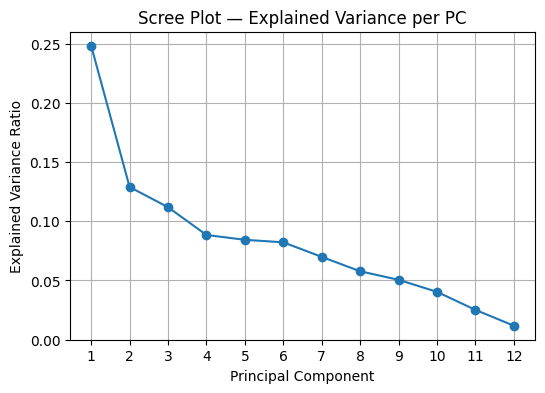

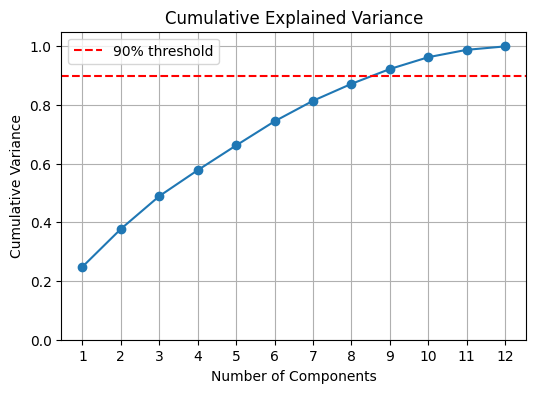


Explained variance + cumulative variance per component:
PC1: variance=0.2485, cumulative=0.2485
PC2: variance=0.1290, cumulative=0.3775
PC3: variance=0.1120, cumulative=0.4895
PC4: variance=0.0885, cumulative=0.5780
PC5: variance=0.0844, cumulative=0.6623
PC6: variance=0.0822, cumulative=0.7446
PC7: variance=0.0699, cumulative=0.8145
PC8: variance=0.0578, cumulative=0.8723
PC9: variance=0.0505, cumulative=0.9228
PC10: variance=0.0404, cumulative=0.9632
PC11: variance=0.0251, cumulative=0.9883
PC12: variance=0.0117, cumulative=1.0000

Number of PCs required to reach 90% variance: 9

Shape of PCA-transformed data: (625229, 9)

Feature importance based on average PCA loadings:


cloudCover            0.253130
is_weekend            0.251723
uvIndex               0.237634
windGust              0.231629
hour                  0.223979
moonPhase             0.196496
distance              0.168313
surge_multiplier      0.165994
windBearing           0.164951
precipIntensity       0.128116
precipIntensityMax    0.127634
precipProbability     0.111472
dtype: float64

In [14]:
print("\n--------------------------------------------------")
print("VARIABLES SELECTED FOR PCA (Numeric Predictors):")
print("--------------------------------------------------")

numeric_cols_final = [
    "hour",
    "distance",
    "precipIntensity",
    "precipProbability",
    "windGust",
    "windBearing",
    "cloudCover",
    "uvIndex",
    "moonPhase",
    "precipIntensityMax",
    "is_weekend",
    "surge_multiplier",  # manually restored
]

for col in numeric_cols_final:
    print(f"• {col}")

print("\nTotal numeric variables used in PCA:", len(numeric_cols_final))

# -----------------------------------------------------------
# 1. STANDARDIZE NUMERIC DATA
# -----------------------------------------------------------

X_num = df_vif[numeric_cols_final]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# -----------------------------------------------------------
# 2. PCA WITH ALL COMPONENTS — FOR PLOTTING FIRST
# -----------------------------------------------------------

pca_full = PCA(n_components=None)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# -----------------------------------------------------------
# 3. SCREE PLOT
# -----------------------------------------------------------

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_var)+1), explained_var, marker="o")
plt.title("Scree Plot — Explained Variance per PC")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, len(explained_var)+1))
plt.grid(True)
plt.show()

# -----------------------------------------------------------
# 4. CUMULATIVE VARIANCE PLOT
# -----------------------------------------------------------

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.axhline(0.90, linestyle="--", color="red", label="90% threshold")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.ylim(0, 1.05)
plt.xticks(range(1, len(cum_var)+1))
plt.grid(True)
plt.legend()
plt.show()

# Show variance numbers
print("\nExplained variance + cumulative variance per component:")
for i, (v, cv) in enumerate(zip(explained_var, cum_var), start=1):
    print(f"PC{i}: variance={v:.4f}, cumulative={cv:.4f}")

# -----------------------------------------------------------
# 5. DETERMINE NUMBER OF COMPONENTS FOR 90% VARIANCE
# -----------------------------------------------------------

threshold = 0.90
n_components_90 = np.searchsorted(cum_var, threshold) + 1
print(f"\nNumber of PCs required to reach 90% variance: {n_components_90}")

# -----------------------------------------------------------
# 6. REFIT PCA WITH THE SELECTED NUMBER OF COMPONENTS
# -----------------------------------------------------------

pca_final = PCA(n_components=n_components_90)
X_pca_final = pca_final.fit_transform(X_scaled)

print("\nShape of PCA-transformed data:", X_pca_final.shape)

# -----------------------------------------------------------
# 7. FEATURE IMPORTANCE VIA PCA LOADINGS
# -----------------------------------------------------------

loadings = pd.DataFrame(
    pca_final.components_.T,
    index=numeric_cols_final,
    columns=[f"PC{i}" for i in range(1, n_components_90 + 1)]
)

importance = loadings.abs().mean(axis=1).sort_values(ascending=False)

print("\nFeature importance based on average PCA loadings:")
display(importance)

#### Defining Feature List

In [15]:
TARGET_COLUMN = "price"

NUMERIC_FEATURES = [
    "hour",
    "distance",
    "precipIntensity",
    "precipProbability",
    "windGust",
    "windBearing",
    "cloudCover",
    "uvIndex",
    "moonPhase",
    "precipIntensityMax",
    "is_weekend",
    "surge_multiplier",
]

CATEGORICAL_FEATURES = [
    "cab_type",
    "name",
    "source",
    "destination",
    "short_summary",
    "day_name",
    "month_name",
]

print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)

Numeric features: ['hour', 'distance', 'precipIntensity', 'precipProbability', 'windGust', 'windBearing', 'cloudCover', 'uvIndex', 'moonPhase', 'precipIntensityMax', 'is_weekend', 'surge_multiplier']
Categorical features: ['cab_type', 'name', 'source', 'destination', 'short_summary', 'day_name', 'month_name']


#### Train-Test Split

In [16]:
all_features = NUMERIC_FEATURES + CATEGORICAL_FEATURES

df_model = df_vif[all_features + [TARGET_COLUMN]].copy()

X = df_model[all_features]
y = df_model[TARGET_COLUMN]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=508,
    shuffle=True,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

X shape: (625229, 19)
y shape: (625229,)
Train shape: (500183, 19)
Test shape: (125046, 19)


#### Transforming Variables

In [17]:
# numeric: just scale, since we dropped all nulls
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# categorical: one hot with drop first like you prefer
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


### Models

In [18]:
model_results = []  # we will append a dict for each model

#### Linear Regression

##### Grid Search

In [19]:
# Linear Regression pipeline
linreg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearRegression())
    ]
)

# Hyperparameter grid
linreg_param_grid = {
    "model__fit_intercept": [True, False],
    "model__positive": [False, True],
}

linreg_grid = GridSearchCV(
    estimator=linreg_pipeline,
    param_grid=linreg_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

linreg_grid.fit(X_train, y_train)

print("Best Linear Regression params:", linreg_grid.best_params_)
print("Best CV RMSE:", -linreg_grid.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Linear Regression params: {'model__fit_intercept': True, 'model__positive': False}
Best CV RMSE: 2.180715995325569


##### Evaluation

In [21]:
# Use the best found Linear Regression model
best_linreg = linreg_grid.best_estimator_

# Predictions on test data
y_pred_linreg = best_linreg.predict(X_test)

# Evaluation metrics
mse_linreg = mean_squared_error(y_test, y_pred_linreg)
rmse_linreg = np.sqrt(mse_linreg)
mae_linreg = mean_absolute_error(y_test, y_pred_linreg)
r2_linreg = r2_score(y_test, y_pred_linreg)

print("\nLinear Regression performance on test set:")
print(f"RMSE: {rmse_linreg:.4f}")
print(f"MAE:  {mae_linreg:.4f}")
print(f"R^2:  {r2_linreg:.4f}")

# Store results for later comparison
model_results.append({
    "model": "LinearRegression",
    "best_params": linreg_grid.best_params_,
    "rmse": rmse_linreg,
    "mae": mae_linreg,
    "r2": r2_linreg,
})


Linear Regression performance on test set:
RMSE: 2.1749
MAE:  1.6155
R^2:  0.9377


##### Most Important Features

In [24]:
def show_linear_model_importance(trained_pipeline, top_n=20, title=""):
    """
    trained_pipeline: fitted Pipeline with steps ["preprocess", "model"]
    model must have a .coef_ attribute
    """
    pre = trained_pipeline.named_steps["preprocess"]
    model = trained_pipeline.named_steps["model"]
    
    feature_names = pre.get_feature_names_out()
    coefs = model.coef_.ravel()  # flatten just in case

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values("abs_coef", ascending=False)

    print(f"\nTop {top_n} features for {title}:")
    display(importance_df.head(top_n))

show_linear_model_importance(best_linreg, top_n=20, title="Linear Regression")


Top 20 features for Linear Regression:


,feature,coef,abs_coef
16,cat__name_Lux Black XL,13.776683,13.776683
20,cat__name_UberPool,-11.550411,11.550411
19,cat__name_Shared,-11.217567,11.217567
21,cat__name_UberX,-10.572490,10.572490
23,cat__name_WAV,-10.559979,10.559979
13,cat__name_Black SUV,9.659838,9.659838
17,cat__name_Lyft,-8.178117,8.178117
15,cat__name_Lux Black,5.052769,5.052769
22,cat__name_UberXL,-4.754632,4.754632
12,cat__cab_type_Uber,3.138631,3.138631


#### Decision Tree Regressor

##### Grid Search

In [22]:
# Decision Tree pipeline
dt_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeRegressor(random_state=508))
    ]
)

# Hyperparameter grid for Decision Tree
dt_param_grid = {
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 20],
    "model__min_samples_leaf": [1, 10],
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring="neg_root_mean_squared_error",  # RMSE
    cv=3,
    n_jobs=-1,
    verbose=1,
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree params:", dt_grid.best_params_)
print("Best CV RMSE:", -dt_grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Best Decision Tree params: {'model__max_depth': 20, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Best CV RMSE: 1.6558281631605662


##### Evaluation

In [23]:
# Best Decision Tree model
best_dt = dt_grid.best_estimator_

# Predictions
y_pred_dt = best_dt.predict(X_test)

# Metrics
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\nDecision Tree performance on test set:")
print(f"RMSE: {rmse_dt:.4f}")
print(f"MAE:  {mae_dt:.4f}")
print(f"R^2:  {r2_dt:.4f}")

# Save for comparison
model_results.append({
    "model": "DecisionTreeRegressor",
    "best_params": dt_grid.best_params_,
    "rmse": rmse_dt,
    "mae": mae_dt,
    "r2": r2_dt,
})


Decision Tree performance on test set:
RMSE: 1.6275
MAE:  1.0688
R^2:  0.9651


##### Most Important Features

In [25]:
def show_tree_model_importance(trained_pipeline, top_n=20, title=""):
    """
    trained_pipeline: fitted Pipeline with steps ["preprocess", "model"]
    model must have .feature_importances_
    """
    pre = trained_pipeline.named_steps["preprocess"]
    model = trained_pipeline.named_steps["model"]
    
    feature_names = pre.get_feature_names_out()
    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print(f"\nTop {top_n} features for {title}:")
    display(importance_df.head(top_n))

show_tree_model_importance(best_dt, top_n=20, title="Decision Tree Regressor")


Top 20 features for Decision Tree Regressor:


,feature,importance
13,cat__name_Black SUV,0.280835
16,cat__name_Lux Black XL,0.244257
1,num__distance,0.128966
15,cat__name_Lux Black,0.101811
19,cat__name_Shared,0.051370
17,cat__name_Lyft,0.044036
21,cat__name_UberX,0.037223
23,cat__name_WAV,0.034839
20,cat__name_UberPool,0.029975
11,num__surge_multiplier,0.018559


#### Linear SVR

##### Grid Search

In [28]:
svr_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearSVR(random_state=508, max_iter=5000))
    ]
)

svr_param_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__epsilon": [0.0, 0.1],
}

svr_grid = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=svr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

svr_grid.fit(X_train, y_train)

print("Best Linear SVR params:", svr_grid.best_params_)
print("Best CV RMSE:", -svr_grid.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Best Linear SVR params: {'model__C': 10.0, 'model__epsilon': 0.1}
Best CV RMSE: 2.2136923743029056


##### Evaluation

In [29]:
best_svr = svr_grid.best_estimator_

y_pred_svr = best_svr.predict(X_test)

mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("\nLinear SVR performance on test set:")
print(f"RMSE: {rmse_svr:.4f}")
print(f"MAE:  {mae_svr:.4f}")
print(f"R^2:  {r2_svr:.4f}")

model_results.append({
    "model": "LinearSVR",
    "best_params": svr_grid.best_params_,
    "rmse": rmse_svr,
    "mae": mae_svr,
    "r2": r2_svr,
})


Linear SVR performance on test set:
RMSE: 2.2065
MAE:  1.5852
R^2:  0.9359


##### Most Important Features

In [30]:
show_linear_model_importance(best_svr, top_n=20, title="Linear SVR")


Top 20 features for Linear SVR:


,feature,coef,abs_coef
16,cat__name_Lux Black XL,15.438719,15.438719
20,cat__name_UberPool,-11.041520,11.041520
23,cat__name_WAV,-10.238586,10.238586
21,cat__name_UberX,-10.237745,10.237745
13,cat__name_Black SUV,9.875505,9.875505
19,cat__name_Shared,-8.801507,8.801507
15,cat__name_Lux Black,6.788396,6.788396
17,cat__name_Lyft,-5.843277,5.843277
22,cat__name_UberXL,-4.968297,4.968297
12,cat__cab_type_Uber,4.883670,4.883670


#### Neural Network Regressor

##### Grid Search

In [31]:
# MLPRegressor pipeline
mlp_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", MLPRegressor(
            random_state=508,
            max_iter=300
        ))
    ]
)

# Hyperparameter grid for MLP
mlp_param_grid = {
    "model__hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "model__alpha": [0.0001, 0.001],
    "model__learning_rate_init": [0.001, 0.01],
}

mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_param_grid,
    scoring="neg_root_mean_squared_error",  # RMSE
    cv=3,
    n_jobs=-1,
    verbose=1
)

mlp_grid.fit(X_train, y_train)

print("Best MLP params:", mlp_grid.best_params_)
print("Best CV RMSE:", -mlp_grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Best MLP params: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (50, 50), 'model__learning_rate_init': 0.001}
Best CV RMSE: 1.6002639281222535


##### Evaluation

In [32]:
best_mlp = mlp_grid.best_estimator_

# Predictions
y_pred_mlp = best_mlp.predict(X_test)

# Metrics
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("\nMLPRegressor performance on test set:")
print(f"RMSE: {rmse_mlp:.4f}")
print(f"MAE:  {mae_mlp:.4f}")
print(f"R^2:  {r2_mlp:.4f}")

# Store for comparison
model_results.append({
    "model": "MLPRegressor",
    "best_params": mlp_grid.best_params_,
    "rmse": rmse_mlp,
    "mae": mae_mlp,
    "r2": r2_mlp,
})


MLPRegressor performance on test set:
RMSE: 1.5729
MAE:  1.0527
R^2:  0.9674


#### Random Forest Regressor

##### Grid Search

In [34]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            random_state=508,
            n_jobs=-1
        ))
    ]
)

rf_param_grid = {
    "model__n_estimators": [40],
    "model__max_depth": [None, 15],
    "model__min_samples_leaf": [1, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest params:", rf_grid.best_params_)
print("Best CV RMSE:", -rf_grid.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Best Random Forest params: {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 40}
Best CV RMSE: 1.612871016018076


##### Evaluation

In [35]:
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest performance on test set:")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE:  {mae_rf:.4f}")
print(f"R^2:  {r2_rf:.4f}")

model_results.append({
    "model": "RandomForestRegressor",
    "best_params": rf_grid.best_params_,
    "rmse": rmse_rf,
    "mae": mae_rf,
    "r2": r2_rf,
})


Random Forest performance on test set:
RMSE: 1.5923
MAE:  1.0491
R^2:  0.9666


##### Most Important Features

In [36]:
show_tree_model_importance(best_rf, top_n=20, title="Random Forest Regressor")


Top 20 features for Random Forest Regressor:


,feature,importance
13,cat__name_Black SUV,0.277947
16,cat__name_Lux Black XL,0.241718
1,num__distance,0.129072
15,cat__name_Lux Black,0.100697
19,cat__name_Shared,0.050786
17,cat__name_Lyft,0.043597
21,cat__name_UberX,0.036198
23,cat__name_WAV,0.035175
20,cat__name_UberPool,0.029643
11,num__surge_multiplier,0.018368


#### XGBoost Regressor

##### Grid Search

In [37]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", XGBRegressor(
            random_state=508,
            n_jobs=-1,
            tree_method="hist",
            objective="reg:squarederror",
        ))
    ]
)

xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 6],
    "model__learning_rate": [0.05, 0.1],
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost params:", xgb_grid.best_params_)
print("Best CV RMSE:", -xgb_grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Best XGBoost params: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200}
Best CV RMSE: 1.5849724505060199


##### Evaluation

In [38]:
best_xgb = xgb_grid.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBoost Regressor performance on test set:")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE:  {mae_xgb:.4f}")
print(f"R^2:  {r2_xgb:.4f}")

model_results.append({
    "model": "XGBRegressor",
    "best_params": xgb_grid.best_params_,
    "rmse": rmse_xgb,
    "mae": mae_xgb,
    "r2": r2_xgb,
})


XGBoost Regressor performance on test set:
RMSE: 1.5709
MAE:  1.0573
R^2:  0.9675


##### Most Important Features

In [39]:
show_tree_model_importance(best_xgb, top_n=20, title="XGBoost Regressor")


Top 20 features for XGBoost Regressor:


,feature,importance
16,cat__name_Lux Black XL,0.392769
13,cat__name_Black SUV,0.265803
15,cat__name_Lux Black,0.087753
19,cat__name_Shared,0.066603
23,cat__name_WAV,0.039271
21,cat__name_UberX,0.036976
17,cat__name_Lyft,0.036923
20,cat__name_UberPool,0.033238
14,cat__name_Lux,0.014421
22,cat__name_UberXL,0.008474


#### KNN Regressor

##### Grid Search

In [42]:
from sklearn.model_selection import train_test_split

# Subsample training data for KNN tuning
X_knn_sub, X_knn_val, y_knn_sub, y_knn_val = train_test_split(
    X_train,
    y_train,
    train_size=50000,   # reduce if needed
    random_state=508,
    shuffle=True,
)

print("KNN tuning subset shapes:")
print("X_knn_sub:", X_knn_sub.shape, "y_knn_sub:", y_knn_sub.shape)
print("X_knn_val:", X_knn_val.shape, "y_knn_val:", y_knn_val.shape)

KNN tuning subset shapes:
X_knn_sub: (50000, 19) y_knn_sub: (50000,)
X_knn_val: (450183, 19) y_knn_val: (450183,)


In [43]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import itertools

# Define hyperparameter grid
k_values = [5, 10]
weight_values = ["uniform", "distance"]
p_values = [1, 2]  # Manhattan vs Euclidean

param_combos = list(itertools.product(k_values, weight_values, p_values))
print("Total KNN combos:", len(param_combos))

best_rmse = np.inf
best_params = None

for n_neighbors, weights, p in param_combos:
    print(f"\nTesting KNN with n_neighbors={n_neighbors}, weights={weights}, p={p}")
    
    knn_pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", KNeighborsRegressor(
                n_neighbors=n_neighbors,
                weights=weights,
                p=p
            ))
        ]
    )
    
    # Fit on subset
    knn_pipeline.fit(X_knn_sub, y_knn_sub)
    
    # Validate on held-out subset
    y_val_pred = knn_pipeline.predict(X_knn_val)
    rmse_val = np.sqrt(mean_squared_error(y_knn_val, y_val_pred))
    
    print(f"Validation RMSE: {rmse_val:.4f}")
    
    if rmse_val < best_rmse:
        best_rmse = rmse_val
        best_params = {
            "n_neighbors": n_neighbors,
            "weights": weights,
            "p": p,
        }

print("\nBest KNN params from manual search:")
print(best_params)
print(f"Best validation RMSE: {best_rmse:.4f}")

Total KNN combos: 8

Testing KNN with n_neighbors=5, weights=uniform, p=1
Validation RMSE: 5.8578

Testing KNN with n_neighbors=5, weights=uniform, p=2
Validation RMSE: 6.0492

Testing KNN with n_neighbors=5, weights=distance, p=1
Validation RMSE: 5.4437

Testing KNN with n_neighbors=5, weights=distance, p=2
Validation RMSE: 5.5138

Testing KNN with n_neighbors=10, weights=uniform, p=1
Validation RMSE: 5.4592

Testing KNN with n_neighbors=10, weights=uniform, p=2
Validation RMSE: 5.6382

Testing KNN with n_neighbors=10, weights=distance, p=1
Validation RMSE: 5.0559

Testing KNN with n_neighbors=10, weights=distance, p=2
Validation RMSE: 5.1502

Best KNN params from manual search:
{'n_neighbors': 10, 'weights': 'distance', 'p': 1}
Best validation RMSE: 5.0559


In [44]:
# Final KNN trained on full training data
best_knn_full = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", KNeighborsRegressor(
            n_neighbors=best_params["n_neighbors"],
            weights=best_params["weights"],
            p=best_params["p"],
        ))
    ]
)

best_knn_full.fit(X_train, y_train)

# Evaluate on test set
y_pred_knn = best_knn_full.predict(X_test)

mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("\nKNN Regressor performance on test set (full train, tuned on subset):")
print(f"RMSE: {rmse_knn:.4f}")
print(f"MAE:  {mae_knn:.4f}")
print(f"R^2:  {r2_knn:.4f}")

model_results.append({
    "model": "KNeighborsRegressor",
    "best_params": best_params,
    "rmse": rmse_knn,
    "mae": mae_knn,
    "r2": r2_knn,
})


KNN Regressor performance on test set (full train, tuned on subset):
RMSE: 3.0511
MAE:  1.9314
R^2:  0.8774


#### Ensemble Method

##### GridSearch

In [45]:
gbr_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=508
        ))
    ]
)

gbr_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
}

gbr_grid = GridSearchCV(
    estimator=gbr_pipeline,
    param_grid=gbr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

gbr_grid.fit(X_train, y_train)

print("Best Gradient Boosting params:", gbr_grid.best_params_)
print("Best CV RMSE:", -gbr_grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Best Gradient Boosting params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV RMSE: 1.7689833332405642


##### Evaluation

In [46]:
best_gbr = gbr_grid.best_estimator_

y_pred_gbr = best_gbr.predict(X_test)

mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("\nGradient Boosting Regressor performance on test set:")
print(f"RMSE: {rmse_gbr:.4f}")
print(f"MAE:  {mae_gbr:.4f}")
print(f"R^2:  {r2_gbr:.4f}")

model_results.append({
    "model": "GradientBoostingRegressor",
    "best_params": gbr_grid.best_params_,
    "rmse": rmse_gbr,
    "mae": mae_gbr,
    "r2": r2_gbr,
})


Gradient Boosting Regressor performance on test set:
RMSE: 1.7591
MAE:  1.2233
R^2:  0.9593


##### Feature Importance

In [47]:
show_tree_model_importance(best_gbr, top_n=20, title="Gradient Boosting Regressor")


Top 20 features for Gradient Boosting Regressor:


,feature,importance
13,cat__name_Black SUV,0.258548
16,cat__name_Lux Black XL,0.224873
1,num__distance,0.119968
19,cat__name_Shared,0.095092
15,cat__name_Lux Black,0.071766
20,cat__name_UberPool,0.059714
23,cat__name_WAV,0.047523
17,cat__name_Lyft,0.045013
21,cat__name_UberX,0.044112
11,num__surge_multiplier,0.019566


### Model Comparison

In [48]:
import pandas as pd

results_df = pd.DataFrame(model_results)

# Sort by RMSE ascending (lower is better)
results_df_sorted = results_df.sort_values("rmse", ascending=True).reset_index(drop=True)

print("Model comparison (sorted by RMSE):")
display(results_df_sorted)

# Identify best model by RMSE
best_idx = results_df_sorted["rmse"].idxmin()
best_model_name = results_df_sorted.loc[best_idx, "model"]

print(f"\nBest model based on RMSE: {best_model_name}")

Model comparison (sorted by RMSE):


,model,best_params,rmse,mae,r2
0,XGBRegressor,"{'model__learning_rate': 0.1, 'model__max_dept...",1.570880,1.057288,0.967507
1,MLPRegressor,"{'model__alpha': 0.001, 'model__hidden_layer_s...",1.572901,1.052728,0.967423
2,RandomForestRegressor,"{'model__max_depth': None, 'model__min_samples...",1.592266,1.049075,0.966616
3,DecisionTreeRegressor,"{'model__max_depth': 20, 'model__min_samples_l...",1.627506,1.068771,0.965122
4,GradientBoostingRegressor,"{'model__learning_rate': 0.1, 'model__max_dept...",1.759102,1.223316,0.959253
5,LinearRegression,"{'model__fit_intercept': True, 'model__positiv...",2.174876,1.615451,0.937716
6,LinearSVR,"{'model__C': 10.0, 'model__epsilon': 0.1}",2.206539,1.585237,0.935889
7,KNeighborsRegressor,"{'n_neighbors': 10, 'weights': 'distance', 'p'...",3.051074,1.931413,0.877422



Best model based on RMSE: XGBRegressor


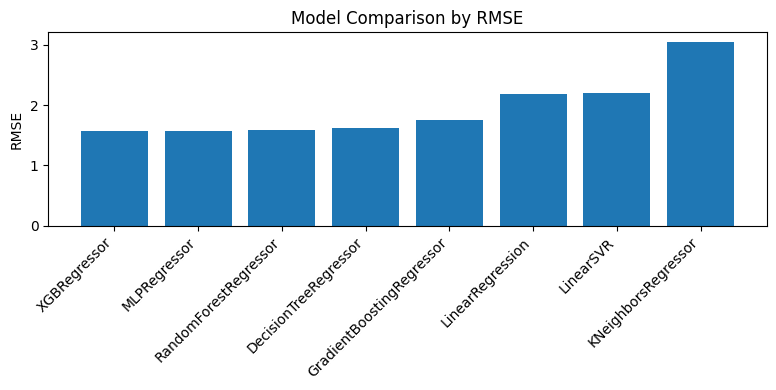

In [49]:
plt.figure(figsize=(8, 4))

models = results_df_sorted["model"]
rmses = results_df_sorted["rmse"]

bars = plt.bar(models, rmses)
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.tight_layout()
plt.show()

### Plots

#### Residual Plot

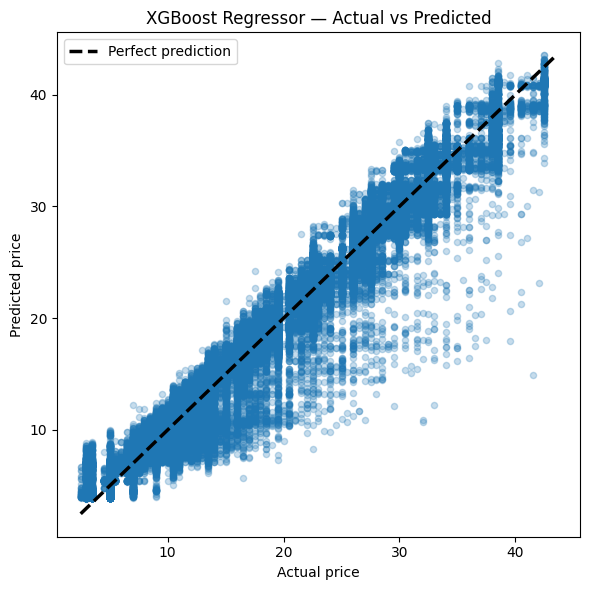

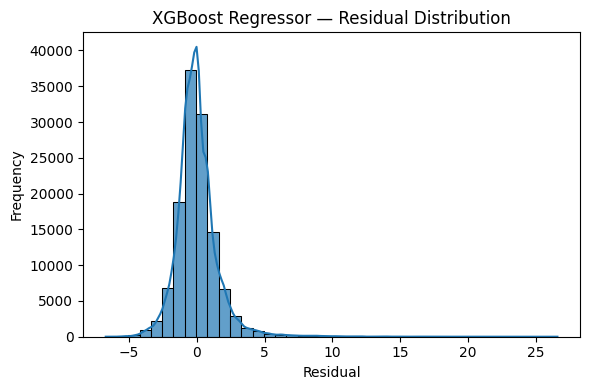

In [61]:
# ============================================================
# Cleaner residual diagnostics with clearer reference lines
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Predictions
y_true = np.array(y_test).ravel()
y_pred = final_model.predict(X_test).ravel()
residuals = y_true - y_pred

# Choose soft blue for dots, dark gray for reference lines
dot_color = "#1f77b4"
line_color = "black"

# 1) Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.25, color=dot_color, s=20)

# Diagonal reference line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2.5,
    color=line_color,
    label="Perfect prediction"
)

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("XGBoost Regressor — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Residual histogram
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True, color=dot_color, edgecolor="black", alpha=0.7)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("XGBoost Regressor — Residual Distribution")
plt.tight_layout()
plt.show()

#### QQ Plot

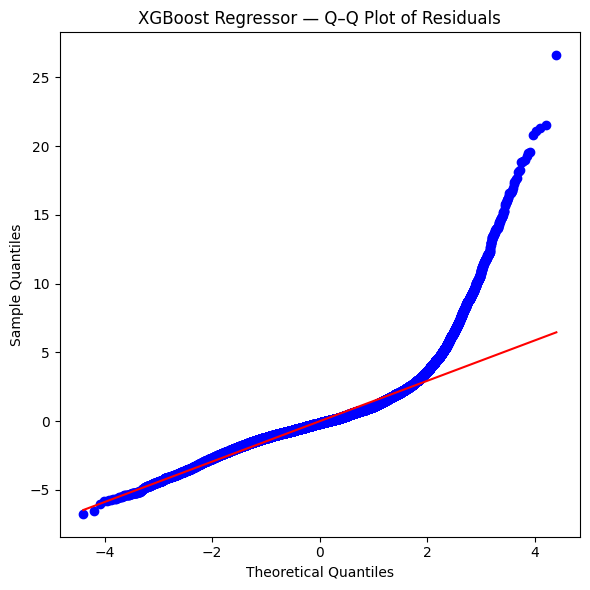

In [62]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# Compute residuals
y_true = np.array(y_test).ravel()
y_pred = final_model.predict(X_test).ravel()
residuals = y_true - y_pred

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)

plt.title("XGBoost Regressor — Q–Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.tight_layout()
plt.show()

#### Heteroscedasticity Plot

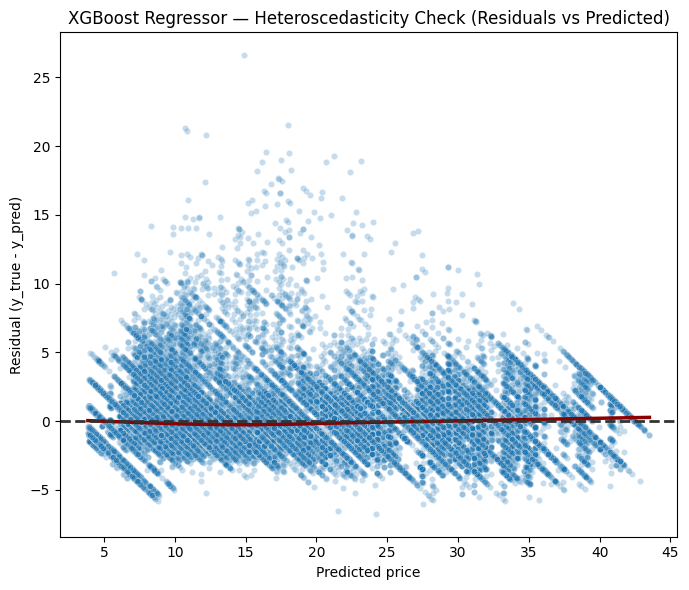

In [63]:
y_true = np.array(y_test).ravel()
y_pred = final_model.predict(X_test).ravel()
residuals = y_true - y_pred

plt.figure(figsize=(7, 6))

# Scatter: residuals vs predictions
sns.scatterplot(x=y_pred, y=residuals, alpha=0.25, s=20, color="#1f77b4")

# LOESS smoothing line (trend)
sns.regplot(
    x=y_pred,
    y=residuals,
    scatter=False,
    lowess=True,
    color="darkred",
    line_kws={"linewidth": 2.5},
)

# Zero reference line
plt.axhline(0, linestyle="--", linewidth=2, color="#333333")

plt.xlabel("Predicted price")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("XGBoost Regressor — Heteroscedasticity Check (Residuals vs Predicted)")
plt.tight_layout()
plt.show()

### Final Feature Importance


Top 20 features for XGBoost Regressor:


,feature,importance
0,cat__name_Lux Black XL,0.392769
1,cat__name_Black SUV,0.265803
2,cat__name_Lux Black,0.087753
3,cat__name_Shared,0.066603
4,cat__name_WAV,0.039271
5,cat__name_UberX,0.036976
6,cat__name_Lyft,0.036923
7,cat__name_UberPool,0.033238
8,cat__name_Lux,0.014421
9,cat__name_UberXL,0.008474


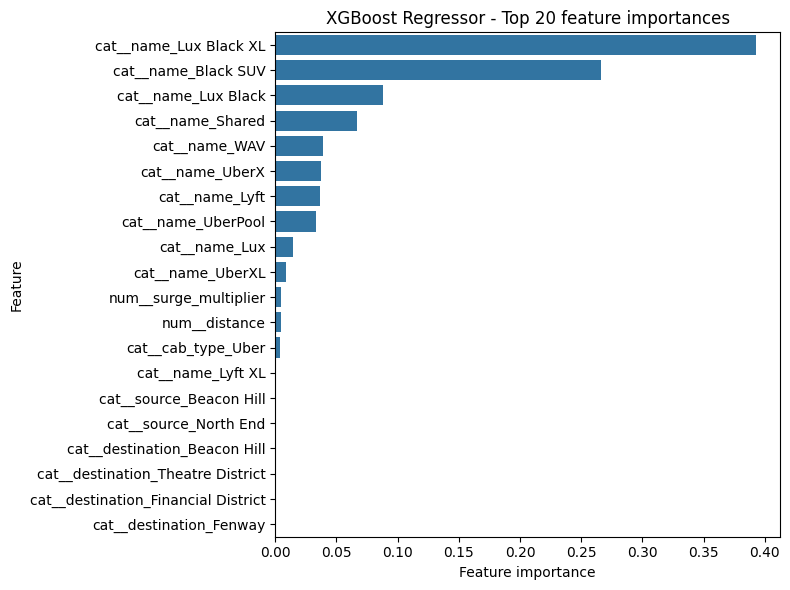

In [56]:
pre = final_model.named_steps["preprocess"]
model = final_model.named_steps["model"]

# Get feature names from the preprocessor
feature_names = pre.get_feature_names_out()

# Get importances from XGBoost
importances = model.feature_importances_

fi_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# Top k most important features
top_k = 20
fi_top = fi_df.head(top_k)

print(f"\nTop {top_k} features for {final_model_name}:")
display(fi_top)

# Horizontal bar plot for feature importance
plt.figure(figsize=(8, 6))
sns.barplot(
    data=fi_top,
    x="importance",
    y="feature",
    orient="h"
)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title(f"{final_model_name} - Top {top_k} feature importances")
plt.tight_layout()
plt.show()

### Model Deployment

In [52]:
import os
from joblib import dump

# Make sure models folder exists
os.makedirs("../models", exist_ok=True)

# Path to save the final model
model_path = "../models/xgb_best_model.joblib"

# Save the full pipeline (preprocessor + XGBRegressor)
dump(best_xgb, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ../models/xgb_best_model.joblib
